# Ethiopia Food Prices — 04 SPIKE ANALYSIS

Defines and detects price spikes in the cleaned dataset, then characterizes when, where, and in which
commodities they happen. This notebook produces a spike-flagged dataset that `10 SPIKE CLASSIFICATION`
will later use as a modelling target.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 20)

df = pd.read_csv('../data/eth_food_prices_clean.csv', parse_dates=['date'])
food = df[(df['category'] != 'non-food') & (df['pricetype'] == 'Retail')].copy()
print(f'{len(food):,} retail food-price rows')


51,071 retail food-price rows


## 4.1 Defining a "spike"

We work at the **market x commodity_unit** series level (one time series per market/commodity/unit
combination), using `usdprice` so currency depreciation doesn't get mistaken for a spike.

A naive fixed threshold (e.g. "+20% month-over-month") doesn't work well here because different
commodities have very different baseline volatility — teff being 10% more volatile than usual is normal,
onions being 10% more volatile might not be. So instead we use a **rolling z-score of the month-over-month
percentage change**:

1. Compute month-over-month `% change` for each market/commodity_unit series.
2. Compute a trailing rolling mean & std of that `% change` (12-month window, minimum 6 observations).
3. `z = (pct_change - rolling_mean) / rolling_std`
4. Flag as a **spike** where `z > 2` (unusually large *increase*) and a **drop** where `z < -2` (unusually
   large *decrease*), relative to that series' own recent volatility.

This adapts to each series' own behaviour instead of applying one global rule to very different
commodities.


In [3]:
food = food.sort_values(['market', 'commodity_unit', 'date'])
grp = food.groupby(['market', 'commodity_unit'], observed=True)

food['pct_change'] = grp['usdprice'].pct_change() * 100

def rolling_z(s):
    roll_mean = s.rolling(window=12, min_periods=6).mean()
    roll_std = s.rolling(window=12, min_periods=6).std()
    return (s - roll_mean) / roll_std

food['pct_change_z'] = grp['pct_change'].transform(rolling_z)

food['is_spike'] = food['pct_change_z'] > 2
food['is_drop'] = food['pct_change_z'] < -2

n_series = food.groupby(['market', 'commodity_unit'], observed=True).ngroups
print(f'{n_series:,} market x commodity_unit series')
print(f"{food['is_spike'].sum():,} spike observations ({food['is_spike'].mean()*100:.2f}% of eligible rows)")
print(f"{food['is_drop'].sum():,} drop observations ({food['is_drop'].mean()*100:.2f}% of eligible rows)")
print(f"{food['pct_change_z'].isna().sum():,} rows have no z-score yet (not enough history in that series)")


1,992 market x commodity_unit series
1,502 spike observations (2.94% of eligible rows)
983 drop observations (1.92% of eligible rows)
10,316 rows have no z-score yet (not enough history in that series)


In [4]:
top_spikes = (
    food[food['is_spike']]
    .sort_values('pct_change', ascending=False)
    [['date', 'admin1', 'market', 'commodity', 'unit', 'pct_change', 'pct_change_z', 'usdprice']]
    .head(15)
)
top_spikes

,date,admin1,market,commodity,unit,pct_change,pct_change_z,usdprice
50452,2025-06-15,Somali,Dolo Ado,Livestock (camel),Head,104129.000000,3.175421,1042.29
28103,2022-05-15,Tigray,Abi Adi,Wheat,100 KG,33482.500000,3.175425,134.33
27399,2022-04-15,Tigray,Adigrat,Wheat,100 KG,27423.809524,3.175425,115.60
32858,2022-12-15,Tigray,Wekro,Wheat,100 KG,27255.000000,3.175424,109.42
27420,2022-04-15,Tigray,Hawzien,Wheat,100 KG,26310.000000,3.175426,105.64
28768,2022-06-15,Tigray,Adwa,Wheat,100 KG,22587.500000,3.175425,127.05
27598,2022-04-15,Tigray,Korem,Wheat,100 KG,20674.468085,3.175425,97.64
27578,2022-04-15,Tigray,Alamata,Wheat,100 KG,19494.230769,3.175415,101.89
33199,2023-01-15,B. Gumuz,Assosa,Livestock (Goat),Head,17827.659574,3.175337,84.26
13321,2020-01-15,SNNPR,Hawassa,Wheat,100 KG,14398.000000,3.175413,72.49


In [6]:
top_drops = (
    food[food['is_drop']]
    .sort_values('pct_change')
    [['date', 'admin1', 'market', 'commodity', 'unit', 'pct_change', 'pct_change_z', 'usdprice']]
    .head(15)
)
top_drops


,date,admin1,market,commodity,unit,pct_change,pct_change_z,usdprice
31888,2022-11-15,B. Gumuz,Assosa,Livestock (Goat),Head,-99.504324,-2.425384,0.47
25724,2022-01-15,Oromia,Beddenno,Livestock (bull),Head,-99.303127,-3.023753,2.73
49525,2025-05-15,Somali,Gode,Sorghum (white),100 KG,-99.032407,-2.524008,0.63
49041,2025-05-15,Amhara,Debark,Beans (fava),100 KG,-98.970664,-2.849869,1.00
58887,2026-05-15,Somali,Kebri Dehar,Sorghum (white),100 KG,-98.947630,-3.004686,1.27
22955,2021-07-15,Oromia,Robe,Teff (mixed),100 KG,-98.928648,-3.157506,1.00
23323,2021-07-15,Somali,Dolo Ado,Livestock (cattle),Head,-98.915260,-2.057081,5.00
62646,2022-12-15,Amhara,Sekota,Wheat flour,100 KG,-98.897869,-2.770054,0.75
62643,2022-12-15,Amhara,Sekota,Maize (white),100 KG,-98.878430,-2.938779,0.56
49515,2025-05-15,Somali,Charati,Livestock (Sheep),Head,-98.870950,-2.781452,1.00


The largest spikes and drops are dominated by low-liquidity/irregularly-reported market-commodity pairs, where a single reporting gap or a genuinely thin market can produce a large jump — worth keeping in mind when this flag is used downstream (a spike flag on a thinly-reported series is noisier evidence than one on a well-covered series).

## 4.3 Spike frequency over time

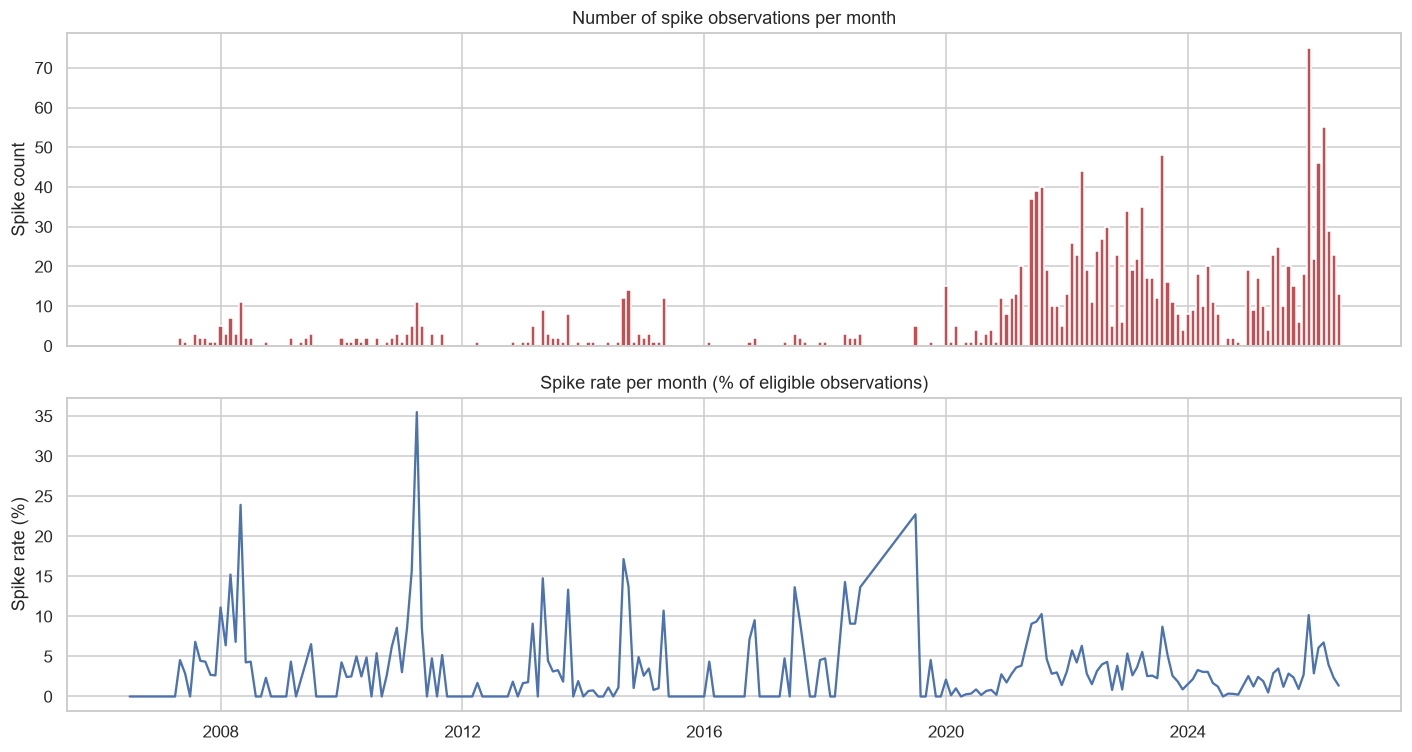

In [7]:
monthly_spikes = food.groupby(food['date'].dt.to_period('M'))['is_spike'].sum()
monthly_total = food.groupby(food['date'].dt.to_period('M'))['is_spike'].count()
monthly_rate = (monthly_spikes / monthly_total * 100)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].bar(monthly_spikes.index.to_timestamp(), monthly_spikes.values, color='#C44E52', width=25)
axes[0].set_title('Number of spike observations per month')
axes[0].set_ylabel('Spike count')

axes[1].plot(monthly_rate.index.to_timestamp(), monthly_rate.values, color='#4C72B0')
axes[1].set_title('Spike rate per month (% of eligible observations)')
axes[1].set_ylabel('Spike rate (%)')

plt.tight_layout()
plt.show()


Spikes are not evenly spread through time — there are visible clusters where a much larger share of
markets/commodities spike simultaneously. Coincident spikes across many series in the same month are the
signature of a **shared shock** (a currency move, a fuel-price jump, a widespread supply disruption) rather
than commodity-specific noise, and are exactly the events worth flagging for a human/analyst to look at.


## 4.4 Spike frequency by region

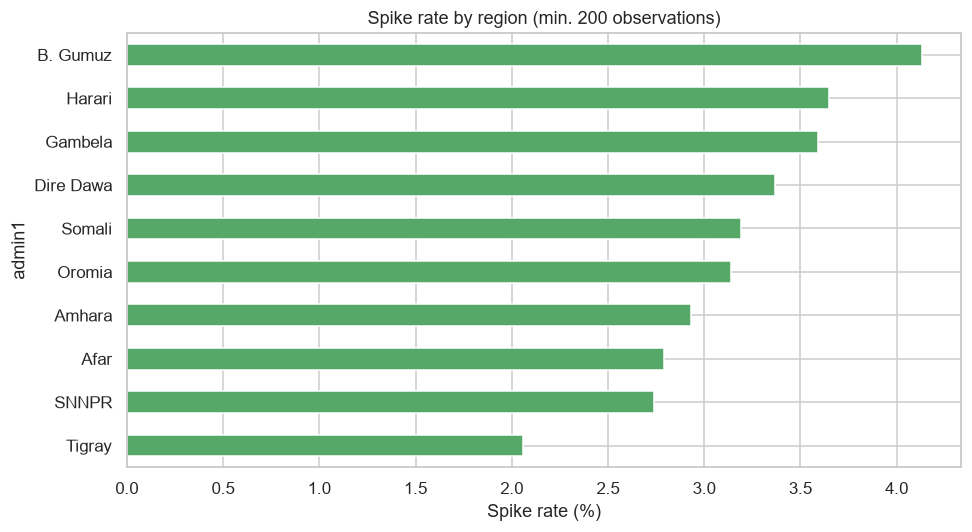

,spike_rate,n_obs,spike_rate_pct
admin1,,,
B. Gumuz,0.041270,630,4.13
Harari,0.036477,1124,3.65
Gambela,0.035865,1422,3.59
Dire Dawa,0.033663,1515,3.37
Somali,0.031925,7079,3.19
Oromia,0.031374,15331,3.14
Amhara,0.029309,8871,2.93
Afar,0.027909,4013,2.79
SNNPR,0.027447,3862,2.74


In [8]:
region_spikes = (
    food.groupby('admin1', observed=True)
    .agg(spike_rate=('is_spike', 'mean'), n_obs=('is_spike', 'count'))
    .query('n_obs >= 200')
    .sort_values('spike_rate', ascending=False)
)
region_spikes['spike_rate_pct'] = (region_spikes['spike_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
region_spikes['spike_rate_pct'].sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Spike rate by region (min. 200 observations)')
ax.set_xlabel('Spike rate (%)')
plt.tight_layout()
plt.show()

region_spikes


Regions differ meaningfully in how often their markets spike — this is consistent with uneven exposure to conflict/access disruption, transport-corridor dependence, and market thinness (fewer, less liquid markets tend to show noisier, spikier series).

## 4.5 Spike frequency by commodity

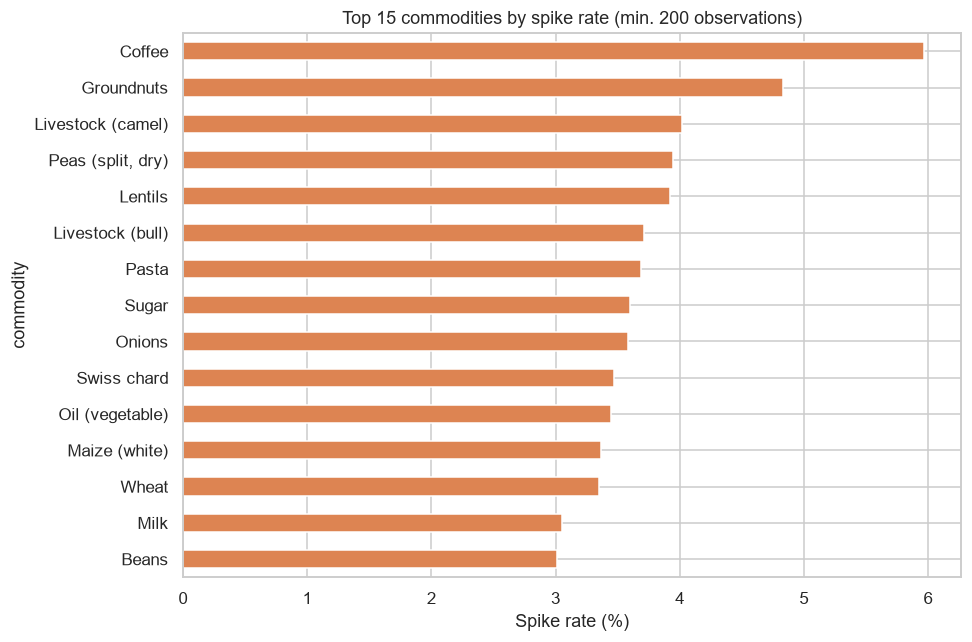

,spike_rate,n_obs,spike_rate_pct
commodity,,,
Coffee,0.059730,1038,5.97
Groundnuts,0.048251,829,4.83
Livestock (camel),0.040161,498,4.02
"Peas (split, dry)",0.039460,963,3.95
Lentils,0.039246,1274,3.92
Livestock (bull),0.037086,755,3.71
Pasta,0.036896,1572,3.69
Sugar,0.035990,778,3.60
Onions,0.035755,867,3.58


In [9]:
commodity_spikes = (
    food.groupby('commodity', observed=True)
    .agg(spike_rate=('is_spike', 'mean'), n_obs=('is_spike', 'count'))
    .query('n_obs >= 200')
    .sort_values('spike_rate', ascending=False)
    .head(15)
)
commodity_spikes['spike_rate_pct'] = (commodity_spikes['spike_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 6))
commodity_spikes['spike_rate_pct'].sort_values().plot(kind='barh', ax=ax, color='#DD8452')
ax.set_title('Top 15 commodities by spike rate (min. 200 observations)')
ax.set_xlabel('Spike rate (%)')
plt.tight_layout()
plt.show()

commodity_spikes


## 4.6 Spike timeline for a specific series

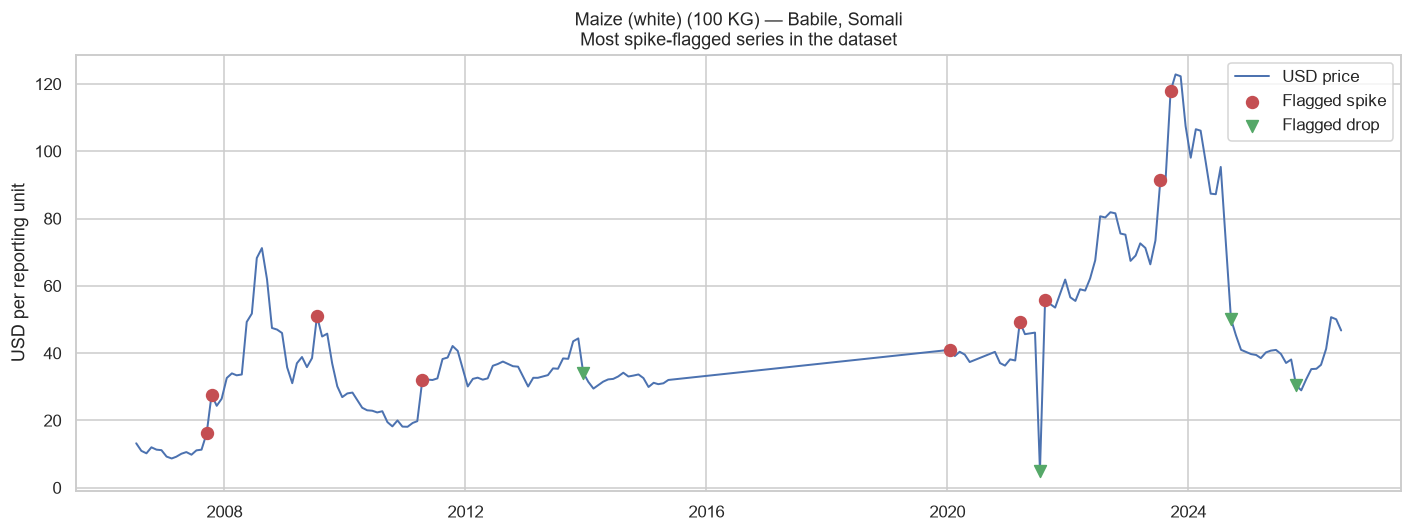

In [10]:
focus_market = food.groupby('market', observed=True)['is_spike'].sum().idxmax()
focus_commodity = (
    food[food['market'] == focus_market]
    .groupby('commodity_unit', observed=True)['is_spike'].sum()
    .idxmax()
)

series = food[(food['market'] == focus_market) & (food['commodity_unit'] == focus_commodity)].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(series['date'], series['usdprice'], color='#4C72B0', linewidth=1.3, label='USD price')
ax.scatter(series.loc[series['is_spike'], 'date'], series.loc[series['is_spike'], 'usdprice'],
           color='#C44E52', s=60, zorder=5, label='Flagged spike')
ax.scatter(series.loc[series['is_drop'], 'date'], series.loc[series['is_drop'], 'usdprice'],
           color='#55A868', marker='v', s=60, zorder=5, label='Flagged drop')
ax.set_title(f'{focus_commodity} — {focus_market}, {series["admin1"].iloc[0]}\nMost spike-flagged series in the dataset')
ax.set_ylabel('USD per reporting unit')
ax.legend()
plt.tight_layout()
plt.show()


Overlaying flags on the raw series is a useful sanity check: the flagged points line up with visually obvious jumps and reversals in the price line, which is a reasonable confidence check on the z-score method before it's used as a modelling target.

## 4.7 Save the spike-flagged dataset

In [11]:
out_path = '../data/eth_food_prices_spikes.csv'
food.to_csv(out_path, index=False)
print(f'Saved {len(food):,} rows x {food.shape[1]} columns -> {out_path}')
print('New columns: pct_change, pct_change_z, is_spike, is_drop')


Saved 51,071 rows x 25 columns -> ../data/eth_food_prices_spikes.csv
New columns: pct_change, pct_change_z, is_spike, is_drop
